In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# set working directory to /home/jmj7858/epifluidlab/sc_nomehic
os.chdir('/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark')

In [2]:
import os
import numpy as np
import pandas as pd


def _parse_summary_file_to_dict(path: str) -> dict:
    """
    Parse a single *.summary.txt file formatted like:
      Key:\t1823185\t100%
    Returns:
      {
        "Key:": {"n": int/float, "pct": float or np.nan}
      }
    """
    out = {}

    df = pd.read_csv(path, sep="\t", header=None, comment="#", dtype=str)

    for _, row in df.iterrows():
        key = str(row.iloc[0]).strip()
        if key == "" or key.lower() == "nan":
            continue

        # value
        val_raw = row.iloc[1] if len(row) > 1 else None
        n = np.nan
        if val_raw is not None and str(val_raw).strip() not in ["", "nan", "None"]:
            v = str(val_raw).strip()
            try:
                n = int(v)
            except ValueError:
                try:
                    n = float(v)
                except ValueError:
                    n = np.nan

        # percent
        pct = np.nan
        if len(row) > 2:
            pct_raw = row.iloc[2]
            if pct_raw is not None and str(pct_raw).strip() not in ["", "nan", "None"]:
                p = str(pct_raw).strip().replace("%", "")
                try:
                    pct = float(p)
                except ValueError:
                    pct = np.nan

        out[key] = {"n": n, "pct": pct}

    return out


def add_alignment_summary_metrics(
    df_cells: pd.DataFrame,
    summary_dir: str,
    suffix: str = ".summary.txt",
    file_pattern: str = "{cell}"
) -> pd.DataFrame:
    """
    Parameters
    ----------
    df_cells : pd.DataFrame
        DataFrame whose index is cell/sample name
    summary_dir : str
        Folder containing summary files
    suffix : str
        Summary filename suffix
    file_pattern : str
        How to map cell -> filename stem

    Returns
    -------
    df_out : pd.DataFrame
        Copy of df_cells with QC columns added.
    """
    df_out = df_cells.copy()

    new_cols = [
        "TotalFragments_n",
        "UniqMapped_n",
        "UniqMapped_pct",
        "UniqMappedMapQ30_n",
        "UniqMappedMapQ30_pct",
        "cis_n",
        "cis_gt1kb_n",
        "trans_n",
        "trans_ratio",
        "cis_per_million_uniqmapq30",
        "summary_path",
    ]
    for c in new_cols:
        if c not in df_out.columns:
            df_out[c] = np.nan

    for cell in df_out.index.astype(str):
        fname = file_pattern.format(cell=cell) + suffix
        path = os.path.join(summary_dir, fname)
        df_out.at[cell, "summary_path"] = path

        if not os.path.exists(path):
            continue

        try:
            d = _parse_summary_file_to_dict(path)

            total = d.get("TotalFragments:", {})
            uniq  = d.get("UniqMapped:", {})
            umq30 = d.get("UniqMappedMapQ30:", {})
            cis   = d.get("UniqMappedMapQ30NoPcrCis:", {})
            cis1k = d.get("UniqMappedMapQ30NoPcrCisMore1kb:", {})
            trans = d.get("UniqMappedMapQ30NoPcrTrans:", {})

            total_n   = total.get("n", np.nan)
            uniq_n    = uniq.get("n", np.nan)
            uniq_pct  = uniq.get("pct", np.nan)
            umq30_n   = umq30.get("n", np.nan)
            umq30_pct = umq30.get("pct", np.nan)
            cis_n     = cis.get("n", np.nan)
            cis1k_n   = cis1k.get("n", np.nan)
            trans_n   = trans.get("n", np.nan)

            df_out.at[cell, "TotalFragments_n"] = total_n
            df_out.at[cell, "UniqMapped_n"] = uniq_n
            df_out.at[cell, "UniqMapped_pct"] = uniq_pct
            df_out.at[cell, "UniqMappedMapQ30_n"] = umq30_n
            df_out.at[cell, "UniqMappedMapQ30_pct"] = umq30_pct
            df_out.at[cell, "cis_n"] = cis_n
            df_out.at[cell, "cis_gt1kb_n"] = cis1k_n
            df_out.at[cell, "trans_n"] = trans_n

            # Derived metrics
            denom_ct = (trans_n + cis_n) if np.isfinite(trans_n) and np.isfinite(cis_n) else np.nan
            if np.isfinite(denom_ct) and denom_ct > 0:
                df_out.at[cell, "trans_ratio"] = trans_n / denom_ct

            if np.isfinite(cis_n) and np.isfinite(umq30_n) and umq30_n > 0:
                df_out.at[cell, "cis_per_million_uniqmapq30"] = cis_n / (umq30_n / 1e6)

            # Optional sanity check:
            # if summary pct is missing or suspicious, recompute uniqmapped pct from counts
            if (not np.isfinite(uniq_pct)) and np.isfinite(uniq_n) and np.isfinite(total_n) and total_n > 0:
                df_out.at[cell, "UniqMapped_pct"] = uniq_n / total_n * 100

            if (not np.isfinite(umq30_pct)) and np.isfinite(umq30_n) and np.isfinite(total_n) and total_n > 0:
                df_out.at[cell, "UniqMappedMapQ30_pct"] = umq30_n / total_n * 100

        except Exception:
            continue

    return df_out


def compute_alignment_metrics_from_table(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Input:
        df_input with columns like:
        CB, TotalFragments, UniqMapped, UniqMappedMapQ30,
        UniqMappedMapQ30NoPcrTrans, UniqMappedMapQ30NoPcrCis,
        UniqMappedMapQ30NoPcrCisMore1kb, etc.

    Returns:
        DataFrame indexed by CB with derived QC metrics.
    """
    df = df_input.copy()

    if "CB" in df.columns:
        df = df.set_index("CB")

    required_cols = [
        "TotalFragments",
        "UniqMapped",
        "UniqMappedMapQ30",
        "UniqMappedMapQ30NoPcrCis",
        "UniqMappedMapQ30NoPcrTrans",
        "UniqMappedMapQ30NoPcrCisMore1kb",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    total_frag = pd.to_numeric(df["TotalFragments"], errors="coerce")
    uniq = pd.to_numeric(df["UniqMapped"], errors="coerce")
    umq30 = pd.to_numeric(df["UniqMappedMapQ30"], errors="coerce")
    cis = pd.to_numeric(df["UniqMappedMapQ30NoPcrCis"], errors="coerce")
    trans = pd.to_numeric(df["UniqMappedMapQ30NoPcrTrans"], errors="coerce")
    cis1kb = pd.to_numeric(df["UniqMappedMapQ30NoPcrCisMore1kb"], errors="coerce")

    # Derived metrics
    uniq_pct = np.where(total_frag > 0, uniq / total_frag * 100, np.nan)
    umq30_pct = np.where(total_frag > 0, umq30 / total_frag * 100, np.nan)

    denom = cis + trans
    trans_ratio = np.where(denom > 0, trans / denom, np.nan)

    cis_per_million = np.where(
        umq30 > 0,
        cis / (umq30 / 1e6),
        np.nan
    )

    df_out = pd.DataFrame({
        "TotalFragments_n": total_frag,
        "UniqMapped_n": uniq,
        "UniqMapped_pct": uniq_pct,
        "UniqMappedMapQ30_n": umq30,
        "UniqMappedMapQ30_pct": umq30_pct,
        "cis_n": cis,
        "cis_gt1kb_n": cis1kb,
        "trans_n": trans,
        "trans_ratio": trans_ratio,
        "cis_per_million_uniqmapq30": cis_per_million,
    }, index=df.index)

    return df_out

In [3]:
import re
from pathlib import Path

def parse_bismark_se_report(report_path: str | Path) -> dict:
    """
    Extract:
      - unique_best_hit_n
      - mapping_efficiency_pct
    from a Bismark *_SE_report.txt file.
    """
    report_path = Path(report_path)

    unique_best_hit_n = None
    mapping_efficiency_pct = None

    with report_path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            # Number of alignments with a unique best hit ...
            m = re.search(r"Number of alignments with a unique best hit.*:\s*([0-9,]+)\s*$", line)
            if m:
                unique_best_hit_n = int(m.group(1).replace(",", ""))
                continue

            # Mapping efficiency: 25.8%
            m = re.search(r"Mapping efficiency:\s*([0-9]*\.?[0-9]+)\s*%\s*$", line)
            if m:
                mapping_efficiency_pct = float(m.group(1))
                continue

    return {
        "report": str(report_path),
        "unique_best_hit_n": unique_best_hit_n,
        "mapping_efficiency_pct": mapping_efficiency_pct,
    }

import pandas as pd
from pathlib import Path

def parse_bismark_se_reports_in_dir(
    report_dir: str | Path,
    glob_pat: str = "*_SE_report.txt",
    suffix: str = ".SE.input_bismark_bt2_SE_report.txt"
) -> pd.DataFrame:
    report_dir = Path(report_dir)
    rows = []

    for rp in sorted(report_dir.glob(glob_pat)):
        d = parse_bismark_se_report(rp)

        # sample name from filename
        name = rp.name
        sample = name
        for suf in [suffix]:
            if sample.endswith(suf):
                sample = sample[: -len(suf)]
                break

        d["sample"] = sample
        rows.append(d)

    df = pd.DataFrame(rows).set_index("sample")
    return df


# nagano

In [4]:
import pandas as pd

# Read file into list
with open("nagano/acc_list.txt", "r") as f:
    nagano_cells = [line.strip() for line in f if line.strip()]

nagano = pd.DataFrame(index=nagano_cells)


In [5]:
nagano = add_alignment_summary_metrics(nagano, summary_dir="/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/nagano/alignment/")

/tmp/ipykernel_2844828/4065772193.py:98: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/nagano/alignment/SRR921540.summary.txt' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_out.at[cell, "summary_path"] = path


In [6]:
nagano

,TotalFragments_n,UniqMapped_n,UniqMapped_pct,UniqMappedMapQ30_n,UniqMappedMapQ30_pct,cis_n,cis_gt1kb_n,trans_n,trans_ratio,cis_per_million_uniqmapq30,summary_path
SRR921540,3487617.0,2740143.0,78.567773,1717273.0,49.239151,27058.0,14458.0,23042.0,0.459920,15756.376534,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921539,9178983.0,6520964.0,71.042337,5018108.0,54.669542,34070.0,16199.0,9997.0,0.226859,6789.411467,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921538,4279639.0,3506132.0,81.925882,2166757.0,50.629434,19158.0,11494.0,7274.0,0.275197,8841.785212,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921537,21222627.0,18179052.0,85.658821,14522656.0,68.430058,62160.0,17838.0,9626.0,0.134093,4280.208799,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921536,1754666.0,1557021.0,88.736033,1008440.0,57.471906,36548.0,11305.0,4118.0,0.101264,36242.116536,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921535,5173536.0,4320540.0,83.512321,2585883.0,49.982894,24830.0,16723.0,3329.0,0.118222,9602.135905,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921534,1882521.0,1390901.0,73.885019,804214.0,42.720055,28545.0,21276.0,2813.0,0.089706,35494.283860,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921533,34143149.0,23659933.0,69.296283,17530229.0,51.343328,91330.0,46228.0,31805.0,0.258294,5209.857783,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921532,2798533.0,2297601.0,82.100193,1341922.0,47.950909,25174.0,20942.0,5273.0,0.173186,18759.659652,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR921531,3703652.0,2918999.0,78.814073,1936315.0,52.281235,83643.0,20143.0,13037.0,0.134847,43197.000488,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...


# dropletHiC

In [7]:
droplethic = pd.read_csv('droplethic/my_project/SRR27586278_hg38.per_cell_qc.valid.tsv', sep='\t')

In [8]:
droplethic_qc = compute_alignment_metrics_from_table(droplethic)
droplethic_qc.head()

,TotalFragments_n,UniqMapped_n,UniqMapped_pct,UniqMappedMapQ30_n,UniqMappedMapQ30_pct,cis_n,cis_gt1kb_n,trans_n,trans_ratio,cis_per_million_uniqmapq30
CB,,,,,,,,,,
BC100166,142288,96613,67.899612,83661,58.796947,81140,3527,2521,0.030134,969866.484981
BC100575,435779,298739,68.552867,263040,60.360871,255255,15868,7785,0.029596,970403.740876
BC10062,273697,189496,69.235688,162995,59.553082,157812,5126,5183,0.031799,968201.478573
BC100661,300319,208376,69.384887,186405,62.069000,180828,9069,5577,0.029919,970081.274644
BC100691,259868,178524,68.697954,159828,61.503533,154669,8887,5159,0.032278,967721.550667


# scnome

In [9]:
scnome_methy = pd.read_csv('summary/trinuc/scnome.chr21.txt', sep='\t')

In [10]:
scnome_mapping = parse_bismark_se_reports_in_dir("/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/scnome/04.alignment", suffix="_trimmed_bismark_bt2_SE_report.txt")
scnome_mapping.index = scnome_mapping.index.str.split('.', n=1).str[1]

In [11]:
scnome = pd.merge(scnome_mapping, scnome_methy, on='sample')

In [12]:
scnome

,sample,report,unique_best_hit_n,mapping_efficiency_pct,noncpg,endo,exo
0,SRR3729642_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,10429993,55.4,0.283,36.099,22.217
1,SRR3729642_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,9633065,53.6,0.391,35.530,22.136
2,SRR3729643_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,7010665,49.7,0.319,38.619,19.267
3,SRR3729643_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,6315299,47.3,0.501,36.932,18.795
4,SRR3729644_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,3785279,39.2,0.267,34.384,18.841
...,...,...,...,...,...,...,...
63,SRR3729680_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,4562471,56.0,0.395,25.722,14.033
64,SRR3729681_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,5336404,63.2,0.440,24.943,13.711
65,SRR3729681_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,4864073,59.9,0.278,23.648,13.847
66,SRR3729682_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,5245024,63.2,0.336,25.376,13.286


# smallwood

In [13]:
smallwood_mapping = parse_bismark_se_reports_in_dir("/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/smallwood/05.align_mm10")

In [14]:
smallwood_methy = pd.read_csv('summary/trinuc/smallwood.chr21.txt', sep='\t')

In [15]:
smallwood = pd.merge(smallwood_mapping, smallwood_methy, on='sample')

In [16]:
smallwood

,sample,report,unique_best_hit_n,mapping_efficiency_pct,noncpg,endo,exo
0,SRR1248444,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,8253387,38.0,2.164,36.441,1.754
1,SRR1248445,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,20019843,38.7,2.209,36.105,1.803
2,SRR1248446,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,29401314,39.1,2.310,37.115,1.868
3,SRR1248447,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,5211863,27.0,2.373,34.514,1.854
4,SRR1248448,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,11008247,43.6,2.297,36.797,1.937
5,SRR1248449,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,12975898,38.8,2.338,36.199,1.957
6,SRR1248450,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,3068777,17.6,2.098,37.231,1.930
7,SRR1248451,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,5784929,33.1,2.261,36.783,1.905
8,SRR1248452,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,8253130,38.0,2.441,35.604,2.018
9,SRR1248453,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,5876202,23.4,2.211,38.485,1.675


# snmCseq2

In [17]:
snmCseq2_mapping = parse_bismark_se_reports_in_dir("/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/snmCseq2/05.align", suffix=".clean_bismark_bt2_SE_report.txt")

In [18]:
snmCseq2_methy = pd.concat([pd.read_csv('summary/trinuc/snmCseq2.chr19.txt', sep='\t'),pd.read_csv('summary/trinuc/snmCseq2.chr21.txt', sep='\t')])

In [19]:
snmCseq2 = pd.merge(snmCseq2_mapping, snmCseq2_methy, on='sample')

In [20]:
snmCseq2

,sample,report,unique_best_hit_n,mapping_efficiency_pct,noncpg,endo,exo
0,SRR6911624_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,1020695,69.9,0.881,83.244,0.808
1,SRR6911624_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,267546,18.3,0.843,81.818,0.625
2,SRR6911625_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,1300146,66.1,3.999,86.512,3.306
3,SRR6911625_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,325707,16.6,2.667,77.108,2.419
4,SRR6911626_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,2113699,73.4,0.859,82.593,1.045
...,...,...,...,...,...,...,...
493,SRR6911870_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,250085,32.1,1.799,77.848,1.021
494,SRR6911871_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,1149724,65.6,1.121,80.345,1.097
495,SRR6911871_2,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,528772,30.2,1.075,79.412,0.821
496,SRR6911872_1,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...,743624,67.1,1.204,81.130,1.284


# snm3Cseq

In [21]:
snm3Cseq_methy = pd.read_csv('summary/trinuc/snmCseq3.chr21.txt', sep='\t')

In [22]:
import pandas as pd

# Read file into list
with open("snmCseq3/acc_list.txt", "r") as f:
    snmCseq3_cells = [line.strip() for line in f if line.strip()]

snmCseq3 = pd.DataFrame(index=snmCseq3_cells)
snmCseq3 = add_alignment_summary_metrics(snmCseq3, summary_dir="/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/snmCseq3/04.bhmem_bam")
snmCseq3 = snmCseq3[snmCseq3['trans_ratio'].notna()]

/tmp/ipykernel_2844828/4065772193.py:98: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/snmCseq3/04.bhmem_bam/SRR21549289.summary.txt' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_out.at[cell, "summary_path"] = path


In [23]:
snmCseq3

,TotalFragments_n,UniqMapped_n,UniqMapped_pct,UniqMappedMapQ30_n,UniqMappedMapQ30_pct,cis_n,cis_gt1kb_n,trans_n,trans_ratio,cis_per_million_uniqmapq30,summary_path
SRR21549289,965851.0,965851.0,100.0,104818.0,10.852399,73246.0,2169.0,14572.0,0.165934,698792.192181,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR21549291,1269796.0,1269796.0,100.0,132712.0,10.451443,91962.0,2206.0,18727.0,0.169186,692944.119597,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR21549292,1292798.0,1292798.0,100.0,133206.0,10.303698,92417.0,2362.0,18863.0,0.169509,693790.069516,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR21549298,2563336.0,2563336.0,100.0,274651.0,10.714592,160025.0,5148.0,34506.0,0.177380,582648.524855,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR21549299,2003872.0,2003872.0,100.0,203883.0,10.174452,119191.0,3371.0,25242.0,0.174766,584604.895945,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
...,...,...,...,...,...,...,...,...,...,...,...
SRR21549431,878963.0,878963.0,100.0,93352.0,10.620697,63777.0,1836.0,13057.0,0.169938,683188.362328,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR21549436,1175607.0,1175607.0,100.0,124786.0,10.614602,84153.0,2330.0,17123.0,0.169073,674378.536054,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR21549437,1018242.0,1018242.0,100.0,109271.0,10.731339,73351.0,1924.0,14266.0,0.162822,671276.001867,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...
SRR21549438,886848.0,886848.0,100.0,97948.0,11.044508,66160.0,1870.0,12968.0,0.163886,675460.448401,/gpfs/projects/b1042/epifluidlab/yoshii/scnome...


In [24]:
import pandas as pd

path = "/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/snmCseq3/alignment/stats/MappingSummary.csv.gz"

snmCseq3 = pd.read_csv(path, compression="gzip", index_col=0)

# unified mapping rate
snmCseq3["mapping_rate"] = (
    snmCseq3["R1MappingRate"] + snmCseq3["R2MappingRate"]
) / 2

snmCseq3.head()

,R1InputReads,R1InputReadsBP,R1WithAdapters,R1QualTrimBP,R1TrimmedReads,R1TrimmedReadsBP,R1TrimmedReadsRate,R1UniqueMappedReads,R1UniqueMappedReadsMapQ30,R1DeduppedReads,...,R2MappingRate,R1DuplicationRate,R2DuplicationRate,R1MappingRateMapQ30,R2MappingRateMapQ30,TotalContacts,CisShortRatio,CisLongRatio,TransRatio,mapping_rate
SRR21549383,1355056,193542987,1401,337416,1339517,165917059,0.988533,1028507,928540,807475,...,70.211301,21.490568,21.455436,69.319016,61.442228,677768,0.971964,0.013199,0.014837,73.496615
SRR21549344,1598059,226592023,2098,436383,1564215,193818368,0.978822,1190049,1076785,888763,...,70.753104,25.317109,25.554445,68.838683,62.510048,764350,0.971053,0.014805,0.014143,73.416367
SRR21549372,1787229,254755254,2309,488273,1761814,218230524,0.985780,1344434,1214866,969086,...,70.504244,27.918663,28.252984,68.955406,62.139745,836419,0.969852,0.015474,0.014673,73.406944
SRR21549338,1975727,281920098,2323,515631,1949034,241568440,0.986490,1444342,1306706,1018364,...,67.889948,29.492876,29.783144,67.043777,59.613144,881884,0.970256,0.013755,0.015990,70.997740
SRR21549360,2468059,347769945,2328,686747,2398081,296971360,0.971647,1818439,1643194,1298851,...,69.339570,28.573298,29.016463,68.521205,60.845267,1118955,0.972429,0.012453,0.015119,72.584246


In [25]:
import pandas as pd
import numpy as np

path = "/gpfs/projects/b1042/epifluidlab/yoshii/scnomehic_paper/benchmark/snmCseq3/alignment/stats/MappingSummary.csv.gz"
snmCseq3 = pd.read_csv(path, compression="gzip", index_col=0)

# sanity check: how different are R1 and R2 unique mapped reads?
snmCseq3["R1_R2_unique_diff_frac"] = (
    (snmCseq3["R1UniqueMappedReads"] - snmCseq3["R2UniqueMappedReads"]).abs()
    / snmCseq3[["R1UniqueMappedReads", "R2UniqueMappedReads"]].mean(axis=1)
)

print(snmCseq3["R1_R2_unique_diff_frac"].describe())

# use the mean unique mapped reads as the plotted count
snmCseq3["mapped_read_n"] = snmCseq3[
    ["R1UniqueMappedReads", "R2UniqueMappedReads"]
].mean(axis=1)

count    100.000000
mean       0.087281
std        0.008133
min        0.072058
25%        0.080803
50%        0.087117
75%        0.092689
max        0.115303
Name: R1_R2_unique_diff_frac, dtype: float64


# MethylHiC

# NOMe-HiC

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import seaborn as sns
import os

def summarize_cellline_qc_from_data(
    prefixes,
    gch_hcg_df,
    chrm_df,
    chr21_df,
    summary_files,
    dataset_label='mixed cellline',
    output_file=None,
    summary_pdf=None,
    utilized_cell_output=None,
    fragnum_threshold=800000,
    noncpg_threshold=3,
    GCH_threshold=1_000_000,
    HCG_threshold=150_000,
    transrate_threshold=0.7,
    cis1kbnum_threshold=2000,
    show_inline=False
):
    """
    Summarize QC metrics from in-memory data for NOMe-HiC cellline analysis.

    Parameters
    ----------
    prefixes : list[str]
        List of sample prefixes (e.g., ['batch1.sc10.ACTTGA', ...])
    gch_hcg_df : pd.DataFrame
        DataFrame with index=sample, columns=['GCH', 'HCG']
    chrm_df : pd.DataFrame
        DataFrame with index=sample, columns=['noncpg', 'endo', 'exo']
    summary_files : list[str]
        List of paths to alignment summary files (same order as prefixes)
    dataset_label : str
        Dataset name label (default 'mixed cellline')
    output_file, summary_pdf, utilized_cell_output : str or None
        Optional output paths for saving results
    *_threshold : numeric
        Filtering thresholds
    show_inline : bool
        If True, display plots inline in Jupyter

    Returns
    -------
    df_all : pd.DataFrame
        All QC metrics
    df_passed : pd.DataFrame
        QC-passing subset
    """

    def plot_hist(df, column, title, xlabel, pdf=None, threshold=None):
        plt.figure(figsize=(8, 5))
        subset = df[column].dropna()
        plt.hist(subset, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        # if threshold is not None:
        #     plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel('Frequency')
        if threshold is not None:
            plt.legend()
        if pdf:
            pdf.savefig()
        if show_inline:
            plt.show()
        plt.close()
    chrm_df.columns = ['noncpg_chrM','endo_chrM','exo_chrM']
    # --- Parse summaries ---
    all_entries = []
    for prefix, summ_path in tqdm(zip(prefixes, summary_files), total=len(prefixes), desc="Parsing QC summaries"):
        entry = {"prefix": prefix, "dataset": dataset_label}
        try:
            align_df = pd.read_csv(summ_path, sep='\t', header=None)
            entry.update({
                'uniquemap': float(align_df[align_df[0]=='UniqMapped:'][2].values[0].strip('%')),
                'mapq30rate': float(align_df[align_df[0]=='UniqMappedMapQ30:'][2].values[0].strip('%')),
                'fragnum': int(align_df[align_df[0]=='TotalFragments:'][1].values[0]),
                'cisnum':int(align_df[align_df[0]=='UniqMappedMapQ30NoPcrCis:'][1].values[0]), 
                'cis1kbnum': int(align_df[align_df[0]=='UniqMappedMapQ30NoPcrCisMore1kb:'][1].values[0]),
                'transnum': int(align_df[align_df[0]=='UniqMappedMapQ30NoPcrTrans:'][1].values[0]),
                'cis1kbrate': float(align_df[align_df[0]=='UniqMappedMapQ30NoPcrCisMore1kb:'][2].values[0].strip('%')),
                'transrate': float(align_df[align_df[0]=='UniqMappedMapQ30NoPcrTrans:'][2].values[0].strip('%')),
            })
        except Exception:
            entry.update({k: np.nan for k in [
                'uniquemap','mapq30rate','fragnum','cisnum','cis1kbnum','transnum','cis1kbrate','transrate'
            ]})

        # Add methylation and GCH/HCG data
        if prefix in chrm_df.index:
            entry.update(chrm_df.loc[prefix].to_dict())
        else:
            entry.update({'noncpg_chrM': np.nan, 'endo_chrM': np.nan, 'exo_chrM': np.nan})

        if prefix in chr21_df.index:
            entry.update(chr21_df.loc[prefix].to_dict())
        else:
            entry.update({'noncpg': np.nan, 'endo': np.nan, 'exo': np.nan})

        if prefix in gch_hcg_df.index:
            entry.update(gch_hcg_df.loc[prefix].to_dict())
        else:
            entry.update({'GCH': np.nan, 'HCG': np.nan})

        all_entries.append(entry)

    df = pd.DataFrame(all_entries)

    # --- Save summary table ---
    if output_file:
        df.to_csv(output_file, sep='\t', index=False)
        print(f"✅ Saved summary table: {output_file}")

    # --- Plot histograms ---
    plot_columns = [
        ('fragnum', 'Raw fragment number', '# of fragments'),
        ('uniquemap', 'Unique mapping rate', 'Mapping rate (%)'),
        ('mapq30rate', 'Fragments MAPQ>30 rate', 'MAPQ>30 (%)'),
        ('cisnum', 'Cis interactions for Hi-C', '# of cis interactions'), 
        ('transnum', 'Trans interactions for Hi-C', '# of trans interactions'),
        ('cis1kbnum', 'Cis interactions >1kb Hi-C', '# of cis interactions'),
        ('transrate', 'Trans interaction rate Hi-C', 'Trans rate (%)'),
        ('cis1kbrate', 'Cis >1kb interaction rate Hi-C', 'Cis >1kb rate (%)'),
        ('noncpg_chrM', 'Non-CpG methylation rate', '% methylation'),
        ('endo_chrM', 'Endogenous methylation rate', '% methylation'),
        ('exo_chrM', 'Exogenous methylation rate', '% methylation'),
        ('noncpg', 'Non-CpG methylation rate', '% methylation'),
        ('endo', 'Endogenous methylation rate', '% methylation'),
        ('exo', 'Exogenous methylation rate', '% methylation'),
        ('GCH', 'Number of GCH sites', 'Number of sites'),
        ('HCG', 'Number of HCG sites', 'Number of sites')
    ]
    thresholds = {
        'fragnum': fragnum_threshold,
        'noncpg': noncpg_threshold,
        'GCH': GCH_threshold,
        'HCG': HCG_threshold,
        'transrate': transrate_threshold,
        'cis1kbnum': cis1kbnum_threshold
    }

    if summary_pdf:
        with PdfPages(summary_pdf) as pdf:
            for col, title, xlabel in plot_columns:
                plot_hist(df, col, title, xlabel, pdf, thresholds.get(col))
        print(f"✅ Saved summary PDF: {summary_pdf}")
    elif show_inline:
        for col, title, xlabel in plot_columns:
            plot_hist(df, col, title, xlabel, None, thresholds.get(col))

    # --- Filtering ---
    df_filtered = df[
        (df['fragnum'] > fragnum_threshold) &
        (df['noncpg'] < noncpg_threshold) &
        (df['GCH'] > GCH_threshold) &
        (df['HCG'] > HCG_threshold) &
        (df['transrate'] > transrate_threshold) &
        (df['cis1kbnum'] > cis1kbnum_threshold)
    ]

    if utilized_cell_output:
        df_filtered['prefix'].to_csv(utilized_cell_output, index=False, header=False)
        print(f"✅ Saved passing cell list: {utilized_cell_output}")

    print(f"✅ {len(df_filtered)}/{len(df)} cells passed QC thresholds")
    return df, df_filtered


In [27]:
# Single-cell NOMe-HiC source = GM12878 cells (sequenced GM, gm_sc_new processing).
# (Replaces the previous IMR90 cell-line source.)
gch_hcg_gm = pd.read_csv('/home/jmj7858/epifluidlab/scnomehic_paper/s1/QC/gm_sc.gch_hcg_count.txt.gz', sep='\t', index_col=0)
chrm_gm    = pd.read_csv('/home/jmj7858/epifluidlab/scnomehic_paper/s1/QC/chrM_gch_hcg/gm.chrM.txt.gz', sep='\t', index_col=0)
chr21_gm   = pd.read_csv('/home/jmj7858/epifluidlab/scnomehic_paper/s1/QC/chrM_gch_hcg/gm.chr21.txt.gz', sep='\t', index_col=0)
gm_prefix = gch_hcg_gm.index.tolist()
# GM prefixes (e.g. scNH_GM_4plex_17_S16.TGACCA) have no ".hg38" suffix.
chrm_gm  = chrm_gm.reindex(gm_prefix)
chr21_gm = chr21_gm.reindex(gm_prefix)
gch_hcg_gm.index = gm_prefix


Parsing QC summaries: 100%|██████████| 188/188 [00:00<00:00, 335.43it/s]
/tmp/ipykernel_2844828/768810450.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


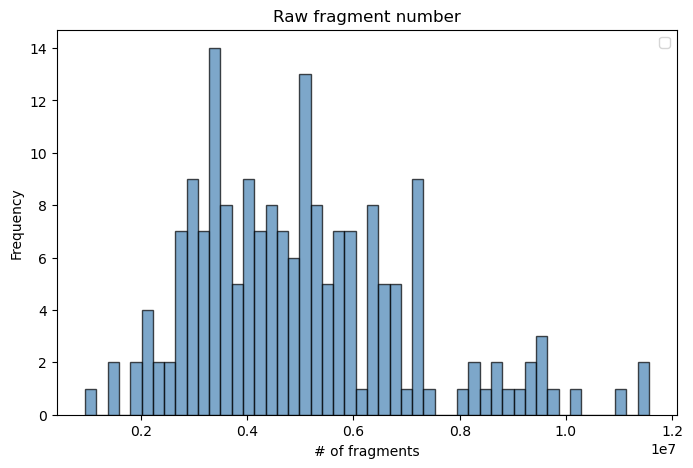

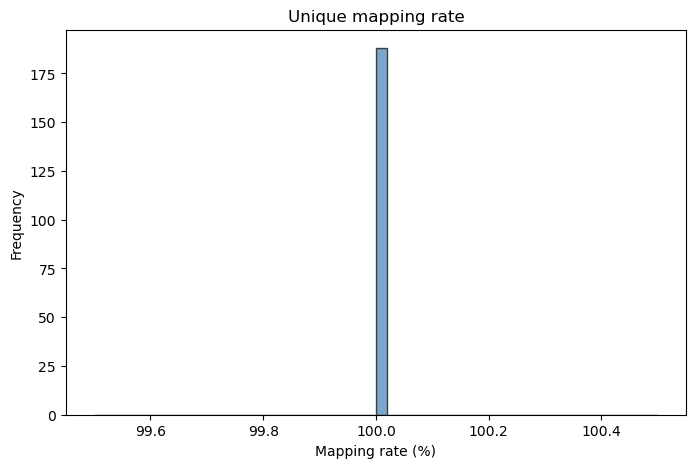

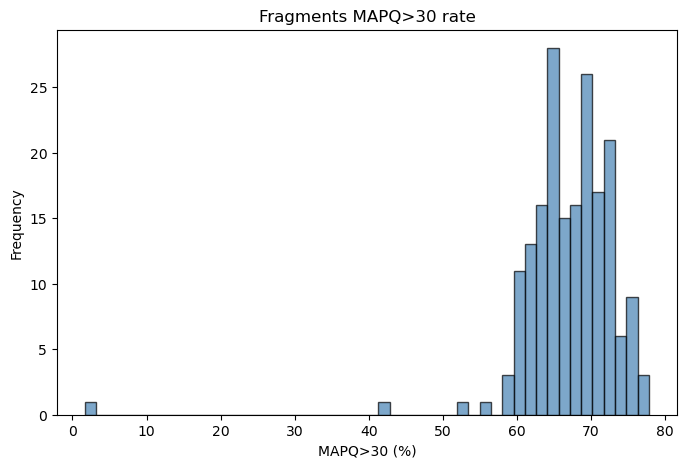

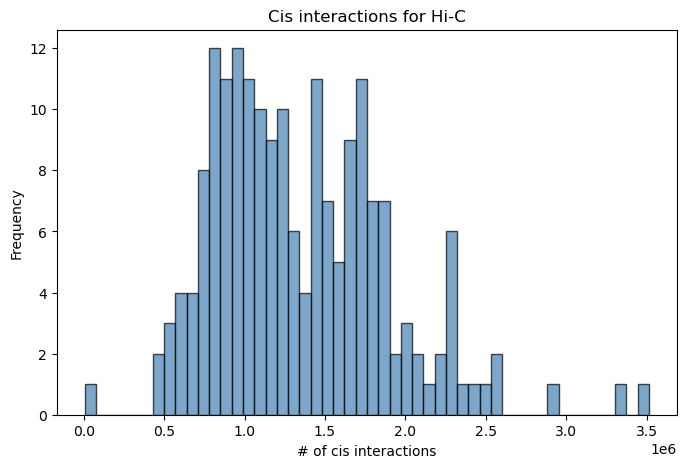

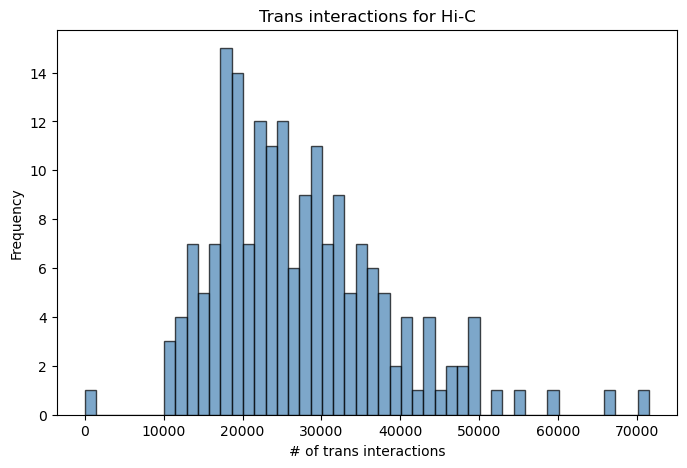

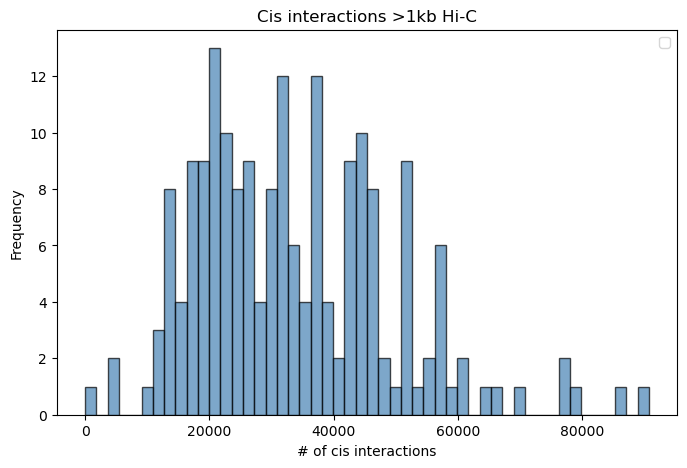

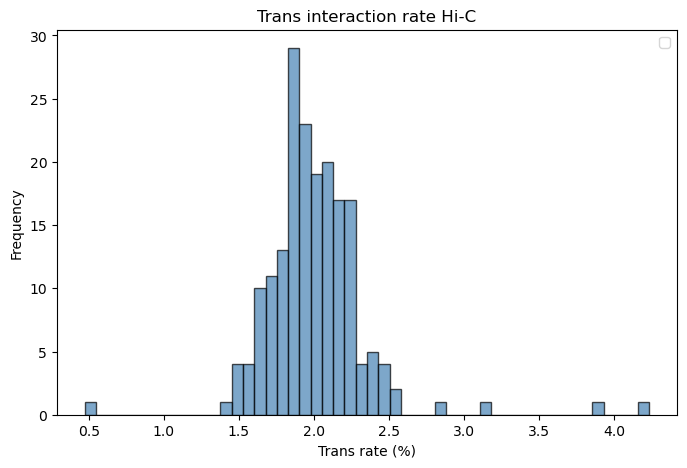

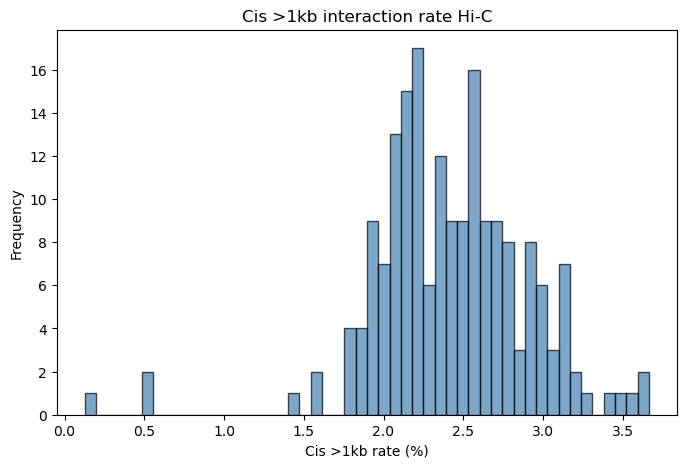

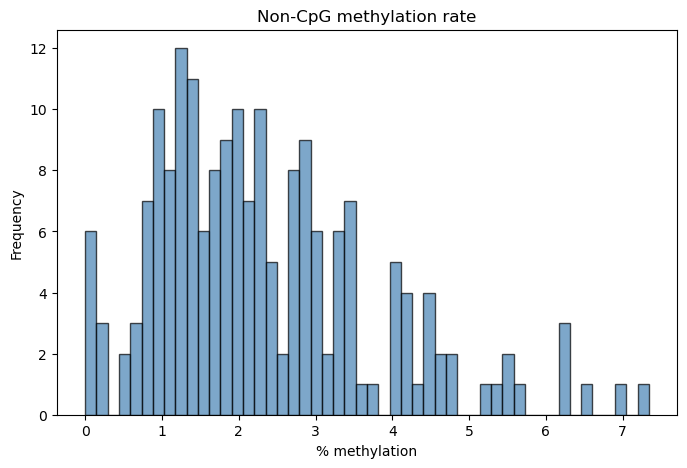

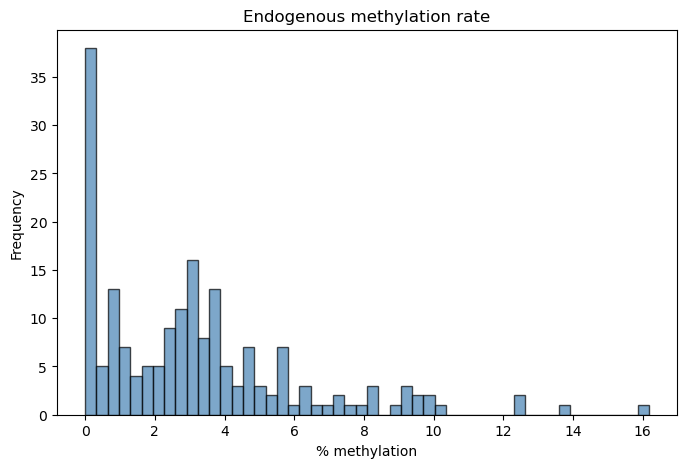

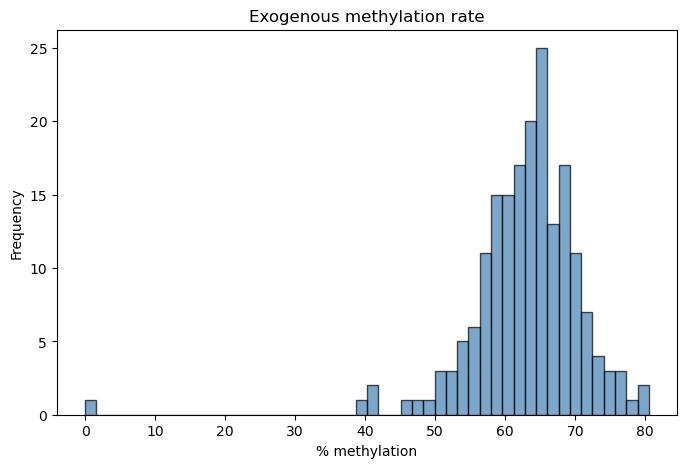

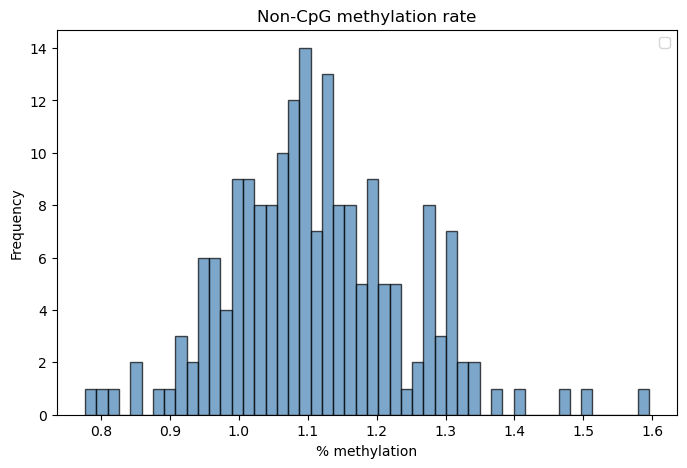

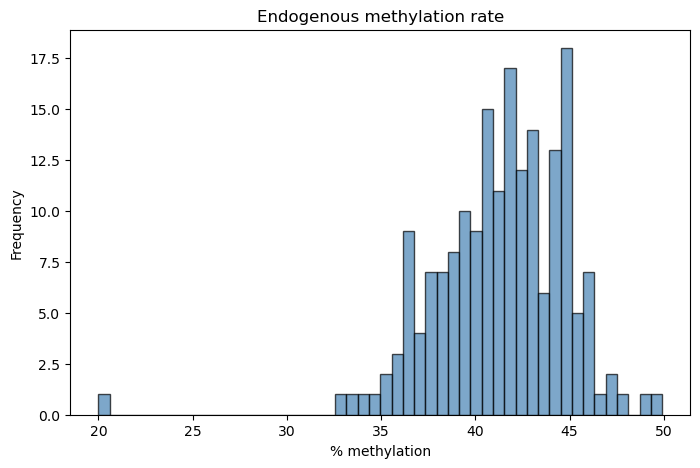

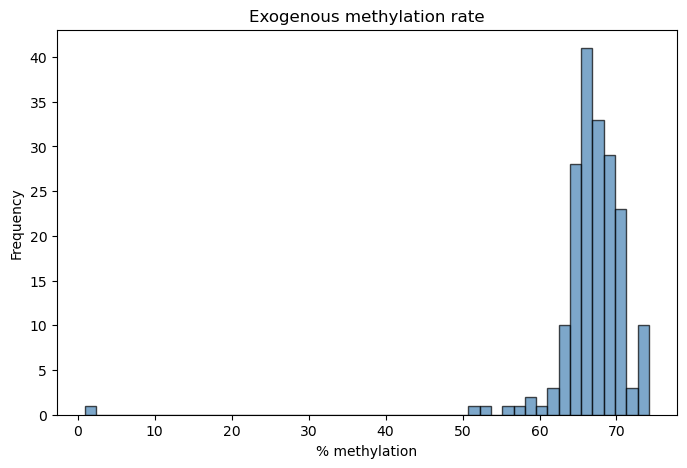

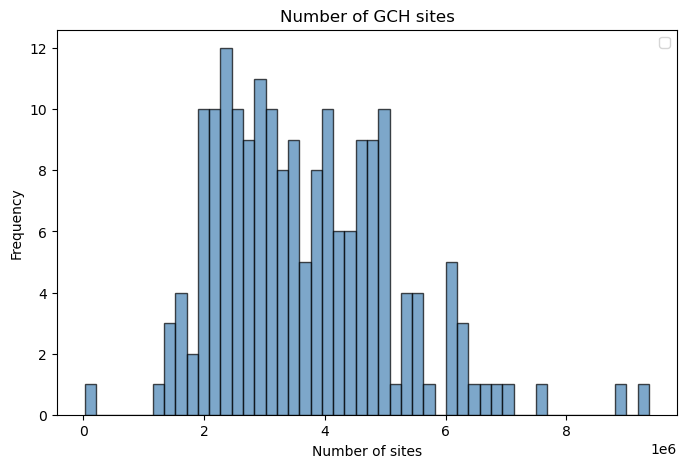

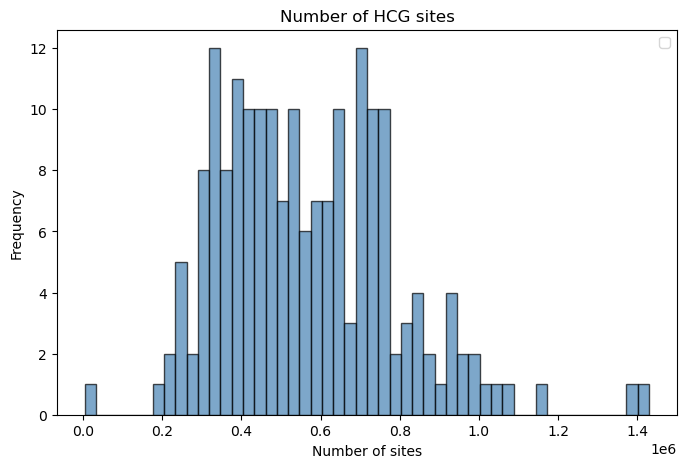

✅ Saved summary PDF: /home/jmj7858/epifluidlab/scnomehic_paper/s1/figures/gm_summary.pdf
✅ Saved passing cell list: /home/jmj7858/epifluidlab/scnomehic_paper/s1/QC/gm_passed.txt
✅ 187/188 cells passed QC thresholds
GM: using 187/188 QC-passing cells for plots


In [28]:
# Prepare inputs
prefixes = gm_prefix
# GM Hi-C alignment summaries (gzipped) from the gm_sc_new snakemake pipeline.
summary_files = [
    f"/home/jmj7858/epifluidlab/sc_nomehic_cellline/gm_sc_new/04.alignment_snakemake/{p}.summary.txt.gz"
    for p in prefixes
]

df_all_gm, df_passed = summarize_cellline_qc_from_data(
    prefixes=prefixes,
    gch_hcg_df=gch_hcg_gm,
    chrm_df=chrm_gm,
    chr21_df=chr21_gm,
    summary_files=summary_files,
    dataset_label='GM cellline',
    summary_pdf='/home/jmj7858/epifluidlab/scnomehic_paper/s1/figures/gm_summary.pdf',
    utilized_cell_output='/home/jmj7858/epifluidlab/scnomehic_paper/s1/QC/gm_passed.txt',
    show_inline=True
)

# Keep only QC-passing GM cells for all downstream plots (the notebook's own QC
# thresholds; drops e.g. scNH_GM_4plex_22_S21.TGACCA). df_passed is that subset.
df_all_gm_unfiltered = df_all_gm
df_all_gm = df_passed.reset_index(drop=True)
print(f"GM: using {len(df_all_gm)}/{len(df_all_gm_unfiltered)} QC-passing cells for plots")


In [29]:
df_all_gm

,prefix,dataset,uniquemap,mapq30rate,fragnum,cisnum,cis1kbnum,transnum,cis1kbrate,transrate,noncpg_chrM,endo_chrM,exo_chrM,noncpg,endo,exo,GCH,HCG
0,scNH_GM_4plex_17_S16.TGACCA,GM cellline,100.0,74.892587,6651187,1937620,57031,40735,2.882749,2.059034,4.433,4.679,65.813,1.500,40.586,73.453,5349089,841221
1,scNH_GM_4plex_39_S38.CGATGT,GM cellline,100.0,72.109669,3471203,1121525,35471,20563,3.105803,1.800474,2.000,3.226,53.791,1.097,39.779,68.528,3123667,483239
2,scNH_GM_4plex_1_S1.GCCAAT,GM cellline,100.0,61.850629,4788868,1145932,33323,22456,2.852049,1.921964,0.224,0.000,58.432,1.079,41.544,71.002,3059568,469774
3,scNH_GM_4plex_34_S33.ATCACG,GM cellline,100.0,64.833268,4125416,1129181,23302,23560,2.021443,2.043824,2.174,4.000,63.700,1.107,40.396,65.992,3150888,489183
4,scNH_GM_4plex_31_S30.TGACCA,GM cellline,100.0,73.142208,6231011,1972733,47823,38594,2.377684,1.918833,0.827,0.000,63.015,1.092,36.778,68.414,5323009,807889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,scNH_GM_4plex_38_S37.GCCAAT,GM cellline,100.0,72.136143,8095437,2299058,56531,41450,2.415330,1.770983,2.682,2.932,68.272,1.004,36.572,68.087,6045640,916921
183,scNH_GM_4plex_6_S5.ATCACG,GM cellline,100.0,60.305449,2614573,712146,21681,13097,2.989481,1.805877,5.392,8.095,64.998,1.317,44.298,68.973,1981586,305571
184,scNH_GM_4plex_13_S12.TGACCA,GM cellline,100.0,70.834295,4632811,1412911,45245,24596,3.147463,1.711018,0.868,2.033,59.969,0.909,40.720,69.494,3864098,596300
185,scNH_GM_4plex_37_S36.TGACCA,GM cellline,100.0,63.464622,2729475,800083,15872,18408,1.939178,2.249017,1.042,6.452,66.760,1.070,39.180,64.867,2221246,339786


In [30]:
def winsorize_to_whiskers(df, value_col, group_col='dataset'):
    fixed = []
    for group, sub in df.groupby(group_col):
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        sub[value_col] = sub[value_col].clip(lower, upper)
        fixed.append(sub)
    return pd.concat(fixed, axis=0)


dataset_order = [
    "nagano",
    "droplethic",
    "scnome",
    "smallwood",
    "snmCseq2",
    "snmCseq3",
    "scnomehic"
]

palette = {
    "nagano":       "#CC79A7",  # Reddish Purple
    "droplethic":   "#0072B2",  # Bright Blue
    "scnome":       "#D55E00",  # Red-Orange
    "smallwood":    "#009E73",  # Bluish Green
    "snmCseq2":     "#E69F00",  # Orange
    "snmCseq3":     "#56B4E9",  # Sky Blue
    "scnomehic":    "#FF0000"   # Red (anchor reference)
}

In [41]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def winsorize_to_whiskers(df, value_col, group_col='dataset'):
    fixed = []
    for group, sub in df.groupby(group_col, sort=False):
        sub = sub.copy()
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        sub[value_col] = sub[value_col].clip(lower, upper)
        fixed.append(sub)
    return pd.concat(fixed, axis=0, ignore_index=True)

def to_metric(df, src_col, dataset_name, out_col="mapq30rate"):
    if src_col not in df.columns:
        raise KeyError(f"[{dataset_name}] missing '{src_col}'. Available cols: {list(df.columns)}")
    out = df[[src_col]].copy()
    out = out.rename(columns={src_col: out_col})
    out["dataset"] = dataset_name
    return out

dataset_order = [
    "nagano",
    "droplethic",
    "scnome",
    "smallwood",
    "snmCseq2",
    "snmCseq3",
    "scnomehic"
]

palette = {
    "nagano":       "#CC79A7",
    "droplethic":   "#0072B2",
    "scnome":       "#D55E00",
    "smallwood":    "#009E73",
    "snmCseq2":     "#E69F00",
    "snmCseq3":     "#56B4E9",
    "scnomehic":    "#FF0000"
}

# --- Publication style ---
sns.set_context("paper", font_scale=1.8)
sns.set_style("whitegrid")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# snmCseq3 is redefined upstream (cell that loads MappingSummary.csv.gz) without a
# 'mapping_rate' column. Derive the MAPQ>=30 mapping rate (mean of R1/R2) here so
# this cell is self-contained and consistent with the high-quality rate plotted.
snmCseq3["mapping_rate_mapq30"] = (
    snmCseq3["R1MappingRateMapQ30"] + snmCseq3["R2MappingRateMapQ30"]
) / 2

# --- Combine into tidy table (UNIFY COLUMN NAMES HERE) ---
plot_df_mapq = pd.concat(
    [
        to_metric(nagano,        "UniqMappedMapQ30_pct",   "nagano"),
        to_metric(droplethic_qc, "UniqMappedMapQ30_pct",   "droplethic"),
        to_metric(scnome,        "mapping_efficiency_pct", "scnome"),
        to_metric(smallwood,     "mapping_efficiency_pct", "smallwood"),
        to_metric(snmCseq2,      "mapping_efficiency_pct", "snmCseq2"),
        to_metric(snmCseq3,      "mapping_rate_mapq30",    "snmCseq3"),
        to_metric(df_all_gm,  "mapq30rate",             "scnomehic"),
    ],
    axis=0,
    ignore_index=True,
)

# numeric + finite
plot_df_mapq["mapq30rate"] = pd.to_numeric(plot_df_mapq["mapq30rate"], errors="coerce")
plot_df_mapq = plot_df_mapq[np.isfinite(plot_df_mapq["mapq30rate"])].copy()

# sanity check: fraction -> percent
if plot_df_mapq["mapq30rate"].quantile(0.95) <= 1.5:
    plot_df_mapq["mapq30rate"] *= 100

# confirm all datasets present (prevents "only one violin" surprises)
counts = plot_df_mapq["dataset"].value_counts().reindex(dataset_order)
print("N per dataset:\n", counts)

plot_df_mapq_w = winsorize_to_whiskers(plot_df_mapq, "mapq30rate")

# --- Plot ---
os.makedirs("figures", exist_ok=True)
plt.figure(figsize=(6, 8))

ax = sns.violinplot(
    data=plot_df_mapq_w,
    x="dataset",
    y="mapq30rate",
    inner="box",
    order=dataset_order,
    palette=palette,
    cut=0,
    bw_adjust=0.8,
    linewidth=1.4
)

ax.set_ylim(0, 100)
ax.set_xlabel("")
ax.set_ylabel("MAPQ ≥ 30 Reads (%)", fontsize=18, labelpad=10)
ax.set_title("High-Quality Mapping Rate", fontsize=20, pad=14)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("figures/mapq30rate_violinplot_winsorized.pdf", dpi=300)
plt.savefig("figures/mapq30rate_violinplot_winsorized.png", dpi=300)
plt.show()

KeyError: "[snmCseq3] missing 'mapping_rate'. Available cols: ['R1InputReads', 'R1InputReadsBP', 'R1WithAdapters', 'R1QualTrimBP', 'R1TrimmedReads', 'R1TrimmedReadsBP', 'R1TrimmedReadsRate', 'R1UniqueMappedReads', 'R1UniqueMappedReadsMapQ30', 'R1DeduppedReads', 'R1DeduppedReadsMapQ30', 'R2InputReads', 'R2InputReadsBP', 'R2WithAdapters', 'R2QualTrimBP', 'R2TrimmedReads', 'R2TrimmedReadsBP', 'R2TrimmedReadsRate', 'R2UniqueMappedReads', 'R2UniqueMappedReadsMapQ30', 'R2DeduppedReads', 'R2DeduppedReadsMapQ30', 'CisShortContact', 'CisLongContact', 'TransContact', 'mCHmC', 'mCHCov', 'mCHFrac', 'mCGmC', 'mCGCov', 'mCGFrac', 'mCCCmC', 'mCCCCov', 'mCCCFrac', 'GenomeCov', 'LambdaCYCov', 'LambdaCYFrac', 'FinalmCReads', 'CellInputReadPairs', 'R1MappingRate', 'R2MappingRate', 'R1DuplicationRate', 'R2DuplicationRate', 'R1MappingRateMapQ30', 'R2MappingRateMapQ30', 'TotalContacts', 'CisShortRatio', 'CisLongRatio', 'TransRatio', 'R1_R2_unique_diff_frac', 'mapped_read_n']"

In [33]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def to_metric(df, src_col, dataset_name, out_col):
    if src_col not in df.columns:
        raise KeyError(f"[{dataset_name}] missing '{src_col}'. Available cols: {list(df.columns)}")
    out = df[[src_col]].copy()
    out = out.rename(columns={src_col: out_col})
    out["dataset"] = dataset_name
    return out

def winsorize_to_whiskers(df, value_col, group_col="dataset"):
    fixed = []
    for group, sub in df.groupby(group_col, sort=False):
        sub = sub.copy()
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        sub[value_col] = sub[value_col].clip(lower, upper)
        fixed.append(sub)
    return pd.concat(fixed, axis=0, ignore_index=True)


# --- Publication style ---
sns.set_context("paper", font_scale=1.8)
sns.set_style("whitegrid")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# -----------------------------
# Build tidy table for READ COUNTS
# -----------------------------
plot_df_reads = pd.concat(
    [
        # MAPQ30-style technologies
        to_metric(nagano,        "UniqMappedMapQ30_n", "nagano",      out_col="read_n"),
        to_metric(droplethic_qc, "UniqMappedMapQ30_n", "droplethic",  out_col="read_n"),

        # mapping efficiency / unique best hit technologies
        to_metric(scnome,        "unique_best_hit_n",  "scnome",      out_col="read_n"),
        to_metric(smallwood,     "unique_best_hit_n",  "smallwood",   out_col="read_n"),
        to_metric(snmCseq2,      "unique_best_hit_n",  "snmCseq2",    out_col="read_n"),

        # snmCseq3 from MappingSummary.csv.gz:
        # use mean of R1/R2 uniquely mapped reads
        to_metric(snmCseq3,      "mapped_read_n",      "snmCseq3",    out_col="read_n"),

        # scNOMe-HiC
        to_metric(df_all_gm,  "fragnum",            "scnomehic",   out_col="read_n"),
    ],
    axis=0,
    ignore_index=True
)

# numeric + finite + positive
plot_df_reads["read_n"] = pd.to_numeric(plot_df_reads["read_n"], errors="coerce")
plot_df_reads = plot_df_reads[np.isfinite(plot_df_reads["read_n"])].copy()
plot_df_reads = plot_df_reads[plot_df_reads["read_n"] > 0].copy()

# confirm all datasets present
counts = plot_df_reads["dataset"].value_counts().reindex(dataset_order)
print("N per dataset:\n", counts)

# optional sanity summary by dataset
print(
    plot_df_reads.groupby("dataset")["read_n"]
    .describe()[["count", "mean", "50%", "min", "max"]]
)

# winsorize
plot_df_reads_w = winsorize_to_whiskers(plot_df_reads, "read_n")

# -----------------------------
# Plot
# -----------------------------
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=plot_df_reads_w,
    x="dataset",
    y="read_n",
    inner="box",
    order=dataset_order,
    palette=palette,
    cut=0,
    bw_adjust=0.8,
    linewidth=1.4
)

ax.set_xlabel("")
ax.set_ylabel("Mapped Reads (count)", fontsize=18, labelpad=10)
ax.set_title("Mapped Read Count", fontsize=20, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# counts span orders of magnitude
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))

plt.tight_layout()
plt.savefig("figures/readcount_violinplot_log_winsorized.pdf", dpi=300)
plt.savefig("figures/readcount_violinplot_log_winsorized.png", dpi=300)
plt.show()

NameError: name 'df_all_imr90' is not defined

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- style ---
sns.set_context("paper", font_scale=1.8)
sns.set_style("whitegrid")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

dataset_order = ["nagano", "droplethic", "snmCseq3", "scnomehic"]

palette = {
    "nagano":     "#CC79A7",
    "droplethic": "#0072B2",
    "snmCseq3":   "#56B4E9",
    "scnomehic":  "#FF0000",
}

def _require_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] missing columns: {missing}. Available: {list(df.columns)}")

def _tidy_from_cols(df, name, mapping):
    """
    mapping: dict standardized_name -> source_col
    """
    _require_cols(df, list(mapping.values()), name)
    out = df[list(mapping.values())].copy()
    out = out.rename(columns={v: k for k, v in mapping.items()})
    out["dataset"] = name
    return out

# --- 3 public datasets that already have Hi-C style columns ---
# Adjust these if your exact column names differ
hic_nagano = _tidy_from_cols(
    nagano, "nagano",
    {
        "cis_n": "cis_n",
        "cis_gt1kb_n": "cis_gt1kb_n",
        "trans_ratio": "trans_ratio",
        "cis_per_million_uniqmapq30": "cis_per_million_uniqmapq30",
    }
)

hic_droplethic = _tidy_from_cols(
    droplethic_qc, "droplethic",
    {
        "cis_n": "cis_n",
        "cis_gt1kb_n": "cis_gt1kb_n",
        "trans_ratio": "trans_ratio",
        "cis_per_million_uniqmapq30": "cis_per_million_uniqmapq30",
    }
)

# snmCseq3 comes from MappingSummary.csv.gz and has NO pre-computed Hi-C factors;
# derive them from the raw contact columns (same as the refined cell below).
_require_cols(
    snmCseq3,
    ["CisShortContact", "CisLongContact", "TransRatio",
     "R1UniqueMappedReads", "R2UniqueMappedReads"],
    "snmCseq3",
)
hic_snmCseq3 = pd.DataFrame(index=snmCseq3.index)
hic_snmCseq3["cis_n"] = snmCseq3["CisShortContact"] + snmCseq3["CisLongContact"]
hic_snmCseq3["cis_gt1kb_n"] = snmCseq3["CisLongContact"]
hic_snmCseq3["trans_ratio"] = snmCseq3["TransRatio"]
_mapped_snmCseq3 = snmCseq3[["R1UniqueMappedReads", "R2UniqueMappedReads"]].mean(axis=1)
hic_snmCseq3["cis_per_million_uniqmapq30"] = np.where(
    _mapped_snmCseq3 > 0,
    hic_snmCseq3["cis_gt1kb_n"] / _mapped_snmCseq3 * 1e6,
    np.nan,
)
hic_snmCseq3["dataset"] = "snmCseq3"

# --- scnomehic uses different names; compute the 4th metric ---
_require_cols(df_all_gm, ["cisnum", "cis1kbnum", "transrate", "fragnum"], "scnomehic")

hic_scnomehic = df_all_gm[["cisnum", "cis1kbnum", "transrate", "fragnum"]].copy()
hic_scnomehic = hic_scnomehic.rename(
    columns={
        "cisnum": "cis_n",
        "cis1kbnum": "cis_gt1kb_n",
        "transrate": "trans_ratio",
    }
)
hic_scnomehic["cis_per_million_uniqmapq30"] = (hic_scnomehic["cis_gt1kb_n"] / hic_scnomehic["fragnum"]) * 1e6
hic_scnomehic["dataset"] = "scnomehic"

# --- combine ---
hic_df = pd.concat([hic_nagano, hic_droplethic, hic_snmCseq3, hic_scnomehic], ignore_index=True)

# --- numeric cleanup ---
for c in ["cis_n", "cis_gt1kb_n", "trans_ratio", "cis_per_million_uniqmapq30"]:
    hic_df[c] = pd.to_numeric(hic_df[c], errors="coerce")

hic_df = hic_df.replace([np.inf, -np.inf], np.nan)

# --- trans_ratio normalization: make it percent for plotting ---
# If it's already in 0-100, keep; if it's 0-1, convert to percent.
q95 = hic_df["trans_ratio"].quantile(0.95)
hic_df["trans_ratio_pct"] = hic_df["trans_ratio"] * (100.0 if q95 <= 1.5 else 1.0)

# quick sanity counts
print("N per dataset:\n", hic_df["dataset"].value_counts().reindex(dataset_order))

N per dataset:
 dataset
nagano          15
droplethic    3668
snmCseq3        98
scnomehic      180
Name: count, dtype: int64


In [34]:
os.makedirs("figures", exist_ok=True)

def violin_plot(df, y, title, ylabel, log=False, ylim=None, fname="plot.pdf"):
    plt.figure(figsize=(6, 8))
    ax = sns.violinplot(
        data=df.dropna(subset=[y]),
        x="dataset",
        y=y,
        order=dataset_order,
        palette=palette,
        inner="box",
        cut=0,
        bw_adjust=0.8,
        linewidth=1.4
    )
    ax.set_xlabel("")
    ax.set_title(title, fontsize=20, pad=14)
    ax.set_ylabel(ylabel, fontsize=18, labelpad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    if log:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))
    if ylim is not None:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    plt.savefig(fname.replace(".pdf", ".png"), dpi=300)
    plt.show()

# 1) cis_n (counts) -> log
violin_plot(
    hic_df, "cis_n",
    title="Cis Contacts per Cell",
    ylabel="Cis contacts (count)",
    log=True,
    fname="figures/hic_cis_n_violin.pdf"
)

# 2) cis_gt1kb_n (counts) -> log
violin_plot(
    hic_df, "cis_gt1kb_n",
    title="Cis > 1 kb Contacts per Cell",
    ylabel="Cis > 1kb contacts (count)",
    log=True,
    fname="figures/hic_cis_gt1kb_n_violin.pdf"
)

# 3) trans_ratio (%) -> linear 0-100
violin_plot(
    hic_df, "trans_ratio_pct",
    title="Trans Fraction",
    ylabel="Trans / (Cis + Trans) (%)",
    log=False,
    ylim=(0, 100),
    fname="figures/hic_trans_ratio_violin.pdf"
)

# 4) cis_per_million_uniqmapq30 -> log (often wide range)
violin_plot(
    hic_df, "cis_per_million_uniqmapq30",
    title="Cis >1kb per Million Uniq MAPQ≥30",
    ylabel="Cis >1kb per 1e6 uniq MAPQ≥30",
    log=True,
    fname="figures/hic_cis_per_million_violin.pdf"
)

NameError: name 'hic_df' is not defined

In [35]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- style ---
sns.set_context("paper", font_scale=1.8)
sns.set_style("whitegrid")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

dataset_order = ["nagano", "droplethic", "snmCseq3", "scnomehic"]

palette = {
    "nagano":     "#CC79A7",
    "droplethic": "#0072B2",
    "snmCseq3":   "#56B4E9",
    "scnomehic":  "#FF0000",
}

def _require_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] missing columns: {missing}. Available: {list(df.columns)}")

def _tidy_from_cols(df, name, mapping):
    """
    mapping: dict standardized_name -> source_col
    """
    _require_cols(df, list(mapping.values()), name)
    out = df[list(mapping.values())].copy()
    out = out.rename(columns={v: k for k, v in mapping.items()})
    out["dataset"] = name
    return out

def winsorize_to_whiskers(df, value_col, group_col="dataset"):
    fixed = []
    for group, sub in df.groupby(group_col, sort=False):
        sub = sub.copy()
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        sub[value_col] = sub[value_col].clip(lower, upper)
        fixed.append(sub)
    return pd.concat(fixed, axis=0, ignore_index=True)

# ---------------------------------
# nagano / droplethic: already standardized
# ---------------------------------
hic_nagano = _tidy_from_cols(
    nagano, "nagano",
    {
        "cis_n": "cis_n",
        "cis_gt1kb_n": "cis_gt1kb_n",
        "trans_ratio": "trans_ratio",
        "cis_per_million_mapped": "cis_per_million_uniqmapq30",
    }
)

hic_droplethic = _tidy_from_cols(
    droplethic_qc, "droplethic",
    {
        "cis_n": "cis_n",
        "cis_gt1kb_n": "cis_gt1kb_n",
        "trans_ratio": "trans_ratio",
        "cis_per_million_mapped": "cis_per_million_uniqmapq30",
    }
)

# ---------------------------------
# snmCseq3 from MappingSummary.csv.gz
# ---------------------------------
_require_cols(
    snmCseq3,
    [
        "CisShortContact", "CisLongContact", "TransRatio",
        "R1UniqueMappedReads", "R2UniqueMappedReads"
    ],
    "snmCseq3"
)

hic_snmCseq3 = snmCseq3[
    ["CisShortContact", "CisLongContact", "TransRatio", "R1UniqueMappedReads", "R2UniqueMappedReads"]
].copy()

hic_snmCseq3["mapped_read_n"] = hic_snmCseq3[
    ["R1UniqueMappedReads", "R2UniqueMappedReads"]
].mean(axis=1)

hic_snmCseq3["cis_n"] = (
    hic_snmCseq3["CisShortContact"] + hic_snmCseq3["CisLongContact"]
)

hic_snmCseq3["cis_gt1kb_n"] = hic_snmCseq3["CisLongContact"]
hic_snmCseq3["trans_ratio"] = hic_snmCseq3["TransRatio"]

hic_snmCseq3["cis_per_million_mapped"] = np.where(
    hic_snmCseq3["mapped_read_n"] > 0,
    hic_snmCseq3["cis_gt1kb_n"] / hic_snmCseq3["mapped_read_n"] * 1e6,
    np.nan
)

hic_snmCseq3 = hic_snmCseq3[
    ["cis_n", "cis_gt1kb_n", "trans_ratio", "cis_per_million_mapped"]
].copy()
hic_snmCseq3["dataset"] = "snmCseq3"

# ---------------------------------
# scnomehic
# ---------------------------------
_require_cols(df_all_gm, ["cisnum", "cis1kbnum", "transrate", "fragnum"], "scnomehic")

hic_scnomehic = df_all_gm[["cisnum", "cis1kbnum", "transrate", "fragnum"]].copy()
hic_scnomehic = hic_scnomehic.rename(
    columns={
        "cisnum": "cis_n",
        "cis1kbnum": "cis_gt1kb_n",
        "transrate": "trans_ratio",
    }
)

hic_scnomehic["cis_per_million_mapped"] = np.where(
    hic_scnomehic["fragnum"] > 0,
    hic_scnomehic["cis_gt1kb_n"] / hic_scnomehic["fragnum"] * 1e6,
    np.nan
)

hic_scnomehic = hic_scnomehic[
    ["cis_n", "cis_gt1kb_n", "trans_ratio", "cis_per_million_mapped"]
].copy()
hic_scnomehic["dataset"] = "scnomehic"

# ---------------------------------
# combine
# ---------------------------------
hic_df = pd.concat(
    [hic_nagano, hic_droplethic, hic_snmCseq3, hic_scnomehic],
    ignore_index=True
)

# ---------------------------------
# numeric cleanup
# ---------------------------------
for c in ["cis_n", "cis_gt1kb_n", "trans_ratio", "cis_per_million_mapped"]:
    hic_df[c] = pd.to_numeric(hic_df[c], errors="coerce")

hic_df = hic_df.replace([np.inf, -np.inf], np.nan)

# Optional sanity checks
print("N per dataset:\n", hic_df["dataset"].value_counts().reindex(dataset_order))
print("\nMissing values by metric:\n", hic_df.groupby("dataset")[["cis_n", "cis_gt1kb_n", "trans_ratio", "cis_per_million_mapped"]].apply(lambda x: x.isna().sum()))

# --- trans_ratio normalization: convert fractions to percent if needed
def convert_trans_to_percent(subdf):
    subdf = subdf.copy()
    vals = pd.to_numeric(subdf["trans_ratio"], errors="coerce")

    # scnomehic transrate is already percent
    if subdf["dataset"].iloc[0] == "scnomehic":
        subdf["trans_ratio_pct"] = vals
    else:
        # for other datasets, infer from scale
        q95 = vals.quantile(0.95)
        if q95 <= 1.0:
            subdf["trans_ratio_pct"] = vals * 100.0
        else:
            subdf["trans_ratio_pct"] = vals
    return subdf

hic_df = (
    hic_df.groupby("dataset", group_keys=False, sort=False)
    .apply(convert_trans_to_percent)
    .reset_index(drop=True)
)
# --- optional winsorization
hic_df_cis_n = winsorize_to_whiskers(hic_df.dropna(subset=["cis_n"]), "cis_n")
hic_df_cis_gt1kb = winsorize_to_whiskers(hic_df.dropna(subset=["cis_gt1kb_n"]), "cis_gt1kb_n")
hic_df_trans = winsorize_to_whiskers(hic_df.dropna(subset=["trans_ratio_pct"]), "trans_ratio_pct")
hic_df_cpm = winsorize_to_whiskers(hic_df.dropna(subset=["cis_per_million_mapped"]), "cis_per_million_mapped")

os.makedirs("figures", exist_ok=True)

def violin_plot(df, y, title, ylabel, log=False, ylim=None, fname="plot.pdf"):
    plt.figure(figsize=(6, 8))
    ax = sns.violinplot(
        data=df.dropna(subset=[y]),
        x="dataset",
        y=y,
        order=dataset_order,
        palette=palette,
        inner="box",
        cut=0,
        bw_adjust=0.8,
        linewidth=1.4
    )
    ax.set_xlabel("")
    ax.set_title(title, fontsize=20, pad=14)
    ax.set_ylabel(ylabel, fontsize=18, labelpad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    if log:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))
    if ylim is not None:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    plt.savefig(fname.replace(".pdf", ".png"), dpi=300)
    plt.show()

# 1) cis_n
violin_plot(
    hic_df_cis_n, "cis_n",
    title="Cis Contacts per Cell",
    ylabel="Cis contacts (count)",
    log=True,
    fname="figures/hic_cis_n_violin.pdf"
)

# 2) cis_gt1kb_n
violin_plot(
    hic_df_cis_gt1kb, "cis_gt1kb_n",
    title="Cis > 1 kb Contacts per Cell",
    ylabel="Cis > 1 kb contacts (count)",
    log=True,
    fname="figures/hic_cis_gt1kb_n_violin.pdf"
)

# 3) trans_ratio_pct
violin_plot(
    hic_df_trans, "trans_ratio_pct",
    title="Trans Fraction",
    ylabel="Trans / (Cis + Trans) (%)",
    log=False,
    ylim=(0, 100),
    fname="figures/hic_trans_ratio_violin.pdf"
)

# 4) cis_per_million_mapped
violin_plot(
    hic_df_cpm, "cis_per_million_mapped",
    title="Cis > 1 kb per Million Mapped Reads",
    ylabel="Cis > 1 kb per 1e6 mapped reads",
    log=True,
    fname="figures/hic_cis_per_million_violin.pdf"
)

NameError: name 'df_all_imr90' is not defined

In [36]:
# --- cis > 1kb rate: fraction of cis contacts that are > 1kb ---
# Uses hic_df / helpers (winsorize_to_whiskers, violin_plot) defined above.
hic_df["cis_gt1kb_rate"] = np.where(
    hic_df["cis_n"] > 0,
    hic_df["cis_gt1kb_n"] / hic_df["cis_n"] * 100.0,
    np.nan,
)

hic_df_cis_gt1kb_rate = winsorize_to_whiskers(
    hic_df.dropna(subset=["cis_gt1kb_rate"]), "cis_gt1kb_rate"
)

print("cis > 1kb rate (%) summary by dataset:")
print(
    hic_df.groupby("dataset")["cis_gt1kb_rate"]
    .describe()
    .reindex(dataset_order)
)

violin_plot(
    hic_df_cis_gt1kb_rate, "cis_gt1kb_rate",
    title="Cis > 1 kb Rate per Cell",
    ylabel="Cis > 1 kb / Cis contacts (%)",
    log=False,
    ylim=(0, 100),
    fname="figures/hic_cis_gt1kb_rate_violin.pdf",
)


NameError: name 'hic_df' is not defined

In [ ]:
# --- Cache / load `hic_df` so the no-nagano plots can run WITHOUT re-running upstream ---
# `hic_df` is built in-memory by the 4-dataset Hi-C cell above and is NOT otherwise
# saved to disk. This cell persists it once (whenever it is present in memory) and
# reloads it from that cache in later sessions. So in a fresh kernel you can run just
# THIS cell + the no-nagano cell below, instead of re-running the whole notebook.
import os
import pandas as pd

HIC_DF_CACHE = "summary/hic_cache/hic_df.csv"
REQUIRED = ["dataset", "cis_n", "cis_gt1kb_n", "trans_ratio_pct", "cis_per_million_mapped"]
os.makedirs(os.path.dirname(HIC_DF_CACHE), exist_ok=True)

if "hic_df" in globals() and all(c in hic_df.columns for c in REQUIRED):
    # upstream was run this session -> refresh the on-disk cache
    hic_df.to_csv(HIC_DF_CACHE, index=False)
    print(f"hic_df present in memory ({len(hic_df)} rows) -> cached to {HIC_DF_CACHE}")
elif os.path.exists(HIC_DF_CACHE):
    # fresh kernel -> load from cache, no upstream needed
    hic_df = pd.read_csv(HIC_DF_CACHE)
    print(f"Loaded hic_df from cache: {HIC_DF_CACHE} ({len(hic_df)} rows)")
else:
    raise RuntimeError(
        "hic_df not in memory and no cache found yet.\n"
        "Run the 4-dataset Hi-C cell above ONCE (the one that builds hic_df with "
        "cis_n / cis_gt1kb_n / trans_ratio_pct / cis_per_million_mapped). This cell "
        f"will then cache it to {HIC_DF_CACHE} for all future sessions."
    )

missing = [c for c in REQUIRED if c not in hic_df.columns]
if missing:
    raise KeyError(f"hic_df is missing required columns: {missing}")
print("dataset counts:\n", hic_df["dataset"].value_counts())


In [ ]:
# --- HiC violins WITHOUT nagano (cis, cis>1kb, trans, cis-per-million) ---
# Reuses `hic_df` built in the 4-dataset Hi-C cell above (nagano, droplethic,
# snmCseq3, scnomehic). Drops nagano and re-plots all four HiC metrics.
# Originals (with nagano) are left untouched; outputs go to *_no_nagano files.
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# order + palette without nagano (same colors as the main figure)
dataset_order_nn = ["droplethic", "snmCseq3", "scnomehic"]
palette_nn = {
    "droplethic": "#0072B2",
    "snmCseq3":   "#56B4E9",
    "scnomehic":  "#FF0000",
}

# drop nagano from the already-built table
hic_df_nn = hic_df[hic_df["dataset"] != "nagano"].copy()

def _winsorize_nn(df, value_col, group_col="dataset"):
    fixed = []
    for _, sub in df.groupby(group_col, sort=False):
        sub = sub.copy()
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1
        sub[value_col] = sub[value_col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        fixed.append(sub)
    return pd.concat(fixed, axis=0, ignore_index=True)

def _violin_nn(df, y, title, ylabel, log=False, ylim=None, fname="plot.pdf"):
    plt.figure(figsize=(6, 8))
    ax = sns.violinplot(
        data=df.dropna(subset=[y]),
        x="dataset", y=y,
        order=dataset_order_nn, palette=palette_nn,
        inner="box", cut=0, bw_adjust=0.8, linewidth=1.4,
    )
    ax.set_xlabel("")
    ax.set_title(title, fontsize=20, pad=14)
    ax.set_ylabel(ylabel, fontsize=18, labelpad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    if log:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))
    if ylim is not None:
        ax.set_ylim(*ylim)
    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    plt.savefig(fname.replace(".pdf", ".png"), dpi=300)
    plt.show()

os.makedirs("figures", exist_ok=True)
print("N per dataset (no nagano):\n",
      hic_df_nn["dataset"].value_counts().reindex(dataset_order_nn))

# 1) cis (cis_n)
_violin_nn(
    _winsorize_nn(hic_df_nn.dropna(subset=["cis_n"]), "cis_n"),
    "cis_n",
    title="Cis Contacts per Cell",
    ylabel="Cis contacts (count)",
    log=True,
    fname="figures/hic_cis_n_violin_no_nagano.pdf",
)

# 2) cis > 1kb (cis_gt1kb_n)
_violin_nn(
    _winsorize_nn(hic_df_nn.dropna(subset=["cis_gt1kb_n"]), "cis_gt1kb_n"),
    "cis_gt1kb_n",
    title="Cis > 1 kb Contacts per Cell",
    ylabel="Cis > 1 kb contacts (count)",
    log=True,
    fname="figures/hic_cis_gt1kb_n_violin_no_nagano.pdf",
)

# 3) trans fraction (trans_ratio_pct) -> linear 0-100
_violin_nn(
    _winsorize_nn(hic_df_nn.dropna(subset=["trans_ratio_pct"]), "trans_ratio_pct"),
    "trans_ratio_pct",
    title="Trans Fraction",
    ylabel="Trans / (Cis + Trans) (%)",
    log=False,
    ylim=(0, 100),
    fname="figures/hic_trans_ratio_violin_no_nagano.pdf",
)

# 4) cis > 1kb per million mapped -> log
_violin_nn(
    _winsorize_nn(hic_df_nn.dropna(subset=["cis_per_million_mapped"]), "cis_per_million_mapped"),
    "cis_per_million_mapped",
    title="Cis > 1 kb per Million Mapped Reads",
    ylabel="Cis > 1 kb per 1e6 mapped reads",
    log=True,
    fname="figures/hic_cis_per_million_violin_no_nagano.pdf",
)


# GCH / HCG detected loci


In [ ]:
# Per-cell detected HCG / GCH loci -- CONSISTENT method.
#   HCG (all 5 methylation methods): destrand (collapse +/- per CpG) + remove GCG
#     by reference genome. Calling = Bismark methylation extraction for
#     scnome/smallwood; YAP/allcools for snmCseq2 (mm10 mouse cells, mates merged)
#     snmCseq3 and snmCAT (bhmem/YAP); BisSNP-1.0.1 NOMe for scnomehic (the exception).
#     No MAPQ-filter inconsistency (avoids BisSNP -mmq 30).
#   GCH (GpC accessibility): NOMe methods ONLY -> scnome (Bismark), snmCAT (YAP), scnomehic (BisSNP NOMe GCH.6plus2). N/A for the bisulfite-only methods.
# Built by each <tech>/codes/compute_hcg.py + summary/make_dataset_summaries.py.
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

gch_hcg = pd.read_csv("summary/gch_hcg_counts/all_methods.summary.txt", sep="\t")
for c in ["GCH_n", "HCG_n"]:
    gch_hcg[c] = pd.to_numeric(gch_hcg[c], errors="coerce")

print("cells per dataset:\n", gch_hcg["dataset"].value_counts())
print("\nmedian loci per dataset:")
print(gch_hcg.groupby("dataset")[["HCG_n", "GCH_n"]].median())
gch_hcg.head()


In [ ]:
# --- publication style (matches the other QC violins) ---
sns.set_context("paper", font_scale=1.8)
sns.set_style("whitegrid")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

palette = {
    "nagano": "#CC79A7", "droplethic": "#0072B2", "scnome": "#D55E00",
    "smallwood": "#009E73", "snmCseq2": "#E69F00", "snmCseq3": "#56B4E9",
    "snmCAT": "#984ea3", "scnomehic": "#FF0000",
}

def winsorize_to_whiskers(df, value_col, group_col="dataset"):
    fixed = []
    for _, sub in df.groupby(group_col, sort=False):
        sub = sub.copy()
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1
        sub[value_col] = sub[value_col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        fixed.append(sub)
    return pd.concat(fixed, axis=0, ignore_index=True)

def loci_violin(df, value_col, order, title, ylabel, fname):
    d = df.dropna(subset=[value_col]).copy()
    d = d[d[value_col] > 0]
    d = winsorize_to_whiskers(d, value_col)
    print("N per dataset:\n", d["dataset"].value_counts().reindex(order))
    plt.figure(figsize=(6, 8))
    ax = sns.violinplot(
        data=d, x="dataset", y=value_col, order=order, palette=palette,
        inner="box", cut=0, bw_adjust=0.8, linewidth=1.4,
    )
    ax.set_xlabel("")
    ax.set_title(title, fontsize=20, pad=14)
    ax.set_ylabel(ylabel, fontsize=18, labelpad=10)
    ax.set_ylim(bottom=0)   # linear y-axis starting at 0 (log can't show 0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig(fname, dpi=300)
    plt.savefig(fname.replace(".pdf", ".png"), dpi=300)
    plt.show()

# HCG (CpG) loci -- all methylation methods
loci_violin(
    gch_hcg, "HCG_n",
    order=["scnome", "smallwood", "snmCseq2", "snmCseq3", "snmCAT", "scnomehic"],
    title="Detected HCG Loci per Cell (GCG removed)",
    ylabel="HCG loci (count)",
    fname="figures/hcg_loci_violin.pdf",
)

# GCH (GpC accessibility) loci -- NOMe methods only
loci_violin(
    gch_hcg, "GCH_n",
    order=["scnome", "snmCAT", "scnomehic"],
    title="Detected GCH Loci per Cell (NOMe only)",
    ylabel="GCH loci (count)",
    fname="figures/gch_loci_violin.pdf",
)
